In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_limpio  = pd.read_csv('df_final.csv')

In [2]:
df_limpio.periodo.value_counts()

periodo
period_5    87047
period_6    86688
period_4    86235
period_3    84384
period_2    82885
period_1    81904
Name: count, dtype: int64

In [3]:
train = df_limpio[df_limpio['periodo'].isin(['period_1', 'period_2', 'period_3', 'period_4'])]
test = df_limpio[df_limpio['periodo'] == 'period_5']
validation = df_limpio[df_limpio['periodo'] == 'period_6']

In [4]:
import pandas as pd

conteo = pd.DataFrame({
    "train": train['target'].value_counts(),
    "test": test['target'].value_counts(),
    "validation": validation['target'].value_counts()
}).fillna(0).astype(int)

# Añadir columna total
conteo['total'] = conteo['train'] + conteo['test'] + conteo['validation']

conteo

,train,test,validation,total
target,,,,
0,291917,75235,73719,440871
1,28773,7510,8529,44812
5,4877,1616,1571,8064
4,4201,1082,1265,6548
2,3569,1043,1020,5632
3,2071,561,584,3216


In [5]:
variables_seleccionadas = [c for c in df_limpio.columns if c != 'target']

**Random Forest**

In [6]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# === VARIABLES SELECCIONADAS (TOP 1 DE CADA GRUPO) ===
features = [c for c in df_limpio.columns if c not in ['target', 'periodo']]

# Separar X e y usando splits por periodo
X_train = train[features]
y_train = train['target']

X_val = validation[features]
y_val = validation['target']

X_test = test[features]
y_test = test['target']

print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")

# Entrenar Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

# Evaluar en validation
y_val_pred = rf.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

# Evaluar en test
y_test_pred = rf.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

Train: (335408, 8), Validation: (86688, 8), Test: (87047, 8)
Validation Accuracy: 0.8516749723145072
              precision    recall  f1-score   support

           0       0.86      0.99      0.92     73719
           1       0.48      0.06      0.10      8529
           2       0.16      0.02      0.03      1020
           3       0.00      0.00      0.00       584
           4       0.49      0.20      0.28      1265
           5       0.34      0.02      0.04      1571

    accuracy                           0.85     86688
   macro avg       0.39      0.21      0.23     86688
weighted avg       0.79      0.85      0.80     86688



c:\Users\jlpar\Escritorio\TECHY\proyectofinaltechy\rftechy\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jlpar\Escritorio\TECHY\proyectofinaltechy\rftechy\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jlpar\Escritorio\TECHY\proyectofinaltechy\rftechy\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

Test Accuracy: 0.8641078957344883
              precision    recall  f1-score   support

           0       0.87      0.99      0.93     75235
           1       0.42      0.05      0.09      7510
           2       0.27      0.02      0.04      1043
           3       0.00      0.00      0.00       561
           4       0.47      0.18      0.26      1082
           5       0.28      0.01      0.02      1616

    accuracy                           0.86     87047
   macro avg       0.38      0.21      0.22     87047
weighted avg       0.80      0.86      0.81     87047



c:\Users\jlpar\Escritorio\TECHY\proyectofinaltechy\rftechy\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jlpar\Escritorio\TECHY\proyectofinaltechy\rftechy\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jlpar\Escritorio\TECHY\proyectofinaltechy\rftechy\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

**XGBClassifier**

In [7]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

# === VARIABLES SELECCIONADAS (TOP 1 DE CADA GRUPO) ===
features = [c for c in df_limpio.columns if c not in ['target', 'periodo']]

# Separar X e y usando splits por periodo
X_train = train[features]
y_train = train['target']

X_val = validation[features]
y_val = validation['target']

X_test = test[features]
y_test = test['target']

print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")

# ===== CÁLCULO DE PESO BALANCEADO =====
n_negative = sum(y_train == 0)
n_positive = sum(y_train == 1)
scale_pos_weight = n_negative / n_positive

print("scale_pos_weight =", scale_pos_weight)

# ===== ENTRENAR XGBOOST =====
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

xgb.fit(X_train, y_train)

# ===== VALIDACIÓN =====
y_val_pred = xgb.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

# ===== TEST FINAL =====
y_test_pred = xgb.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

Train: (335408, 8), Validation: (86688, 8), Test: (87047, 8)
scale_pos_weight = 10.145518367914365


c:\Users\jlpar\Escritorio\TECHY\proyectofinaltechy\rftechy\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:29:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Validation Accuracy: 0.8543397009966778
              precision    recall  f1-score   support

           0       0.86      1.00      0.92     73719
           1       0.52      0.04      0.08      8529
           2       0.51      0.02      0.03      1020
           3       0.00      0.00      0.00       584
           4       0.57      0.23      0.32      1265
           5       0.55      0.03      0.05      1571

    accuracy                           0.85     86688
   macro avg       0.50      0.22      0.23     86688
weighted avg       0.81      0.85      0.80     86688



c:\Users\jlpar\Escritorio\TECHY\proyectofinaltechy\rftechy\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jlpar\Escritorio\TECHY\proyectofinaltechy\rftechy\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jlpar\Escritorio\TECHY\proyectofinaltechy\rftechy\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

Test Accuracy: 0.8666008018656588
              precision    recall  f1-score   support

           0       0.87      1.00      0.93     75235
           1       0.47      0.04      0.07      7510
           2       0.65      0.01      0.02      1043
           3       0.00      0.00      0.00       561
           4       0.55      0.22      0.31      1082
           5       0.51      0.02      0.03      1616

    accuracy                           0.87     87047
   macro avg       0.51      0.21      0.23     87047
weighted avg       0.82      0.87      0.81     87047



c:\Users\jlpar\Escritorio\TECHY\proyectofinaltechy\rftechy\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jlpar\Escritorio\TECHY\proyectofinaltechy\rftechy\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jlpar\Escritorio\TECHY\proyectofinaltechy\rftechy\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

**LIGHTBM**

In [8]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report
import lightgbm as lgb
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

# === VARIABLES SELECCIONADAS (TOP 1 DE CADA GRUPO) ===
features = [c for c in df_limpio.columns if c not in ['target', 'periodo']]

# Separar X e y usando splits por periodo
X_train = train[features]
y_train = train['target']

X_val = validation[features]
y_val = validation['target']

X_test = test[features]
y_test = test['target']

print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")

# ===== ENTRENAR LIGHTGBM =====
lgbm = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    class_weight='balanced'
)

lgbm.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='binary_logloss')

# ===== VALIDACIÓN =====
y_val_pred = lgbm.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

# ===== TEST FINAL =====
y_test_pred = lgbm.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

Train: (335408, 8), Validation: (86688, 8), Test: (87047, 8)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009535 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1539
[LightGBM] [Info] Number of data points in the train set: 335408, number of used features: 8
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
Validation Accuracy: 0.5124930786267996
              precision    recall  f1-score   support

           0       0.96      0.49      0.65     73719
           1       0.26      0.70      0.38      8529
           2       0.09      0.62      0.16      1020
           3       0.03      0.40      0.06       584
           4   

**BalancedBaggingClassifier**

In [9]:
from imblearn.ensemble import BalancedBaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# === VARIABLES SELECCIONADAS (TOP 1 DE CADA GRUPO) ===
features = [c for c in df_limpio.columns if c not in ['target', 'periodo']]

# Separar X e y usando splits por periodo
X_train = train[features]
y_train = train['target']

X_val = validation[features]
y_val = validation['target']

X_test = test[features]
y_test = test['target']

# ===== CREAR BALANCEDBAGGINGCLASSIFIER =====
bbc = BalancedBaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    sampling_strategy='auto',
    replacement=False,
    random_state=42,
    n_jobs=-1
)

# ===== ENTRENAR =====
bbc.fit(X_train, y_train)

# ===== VALIDACIÓN =====
y_val_pred = bbc.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))

# ===== TEST FINAL =====
y_test_pred = bbc.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

Validation Accuracy: 0.510797342192691
              precision    recall  f1-score   support

           0       0.95      0.49      0.65     73719
           1       0.26      0.66      0.38      8529
           2       0.09      0.55      0.15      1020
           3       0.03      0.38      0.05       584
           4       0.14      0.52      0.22      1265
           5       0.09      0.46      0.15      1571

    accuracy                           0.51     86688
   macro avg       0.26      0.51      0.27     86688
weighted avg       0.84      0.51      0.60     86688

Confusion Matrix:
 [[36455 15358  4951  6753  3219  6983]
 [ 1491  5654   167   351   743   123]
 [    2    56   560    40   118   244]
 [   87    89    47   219    33   109]
 [   95   299   132    34   663    42]
 [   97    63   415   229    38   729]]
Test Accuracy: 0.4978459912461084
              precision    recall  f1-score   support

           0       0.96      0.48      0.64     75235
           1       0.

**Advanced Imbalanced Learning Techniques**
**The following sections implement:**

**1. Undersampling - Reduce majority class so minorities reach ~10%**

**2. XGBoost + LightGBM Ensemble - Combined model for better performance**

**3. Contrastive Learning - Learn better representations for minority classes**

**4. Monte Carlo Class Weights - Find optimal weights through random search****

**1. Undersampling Majority Class (Target ~10% for minorities)**

In [10]:
import numpy as np
from collections import Counter
from imblearn.under_sampling import RandomUnderSampler

# Calculate current distribution
class_counts = Counter(y_train)
print("Current class distribution:")
for cls, count in sorted(class_counts.items()):
    pct = count / len(y_train) * 100
    print(f"  Class {cls}: {count} ({pct:.1f}%)")

# Calculate target samples for majority class
minority_counts = {k: v for k, v in class_counts.items() if k != 0}
total_minority = sum(minority_counts.values())
majority_count = class_counts[0]

# Opciones: elige el porcentaje que quieres para las minorías
TARGET_MINORITY_PCT = 20  # Cambiar a 20%, 30%, etc. para reducir más la mayoría

# Si minorías = TARGET_MINORITY_PCT%, entonces mayoría = (100 - TARGET_MINORITY_PCT)%
# total_minority / total = TARGET_MINORITY_PCT / 100
# total = total_minority / (TARGET_MINORITY_PCT / 100)
# target_majority = total - total_minority
target_majority = int(total_minority * (100 - TARGET_MINORITY_PCT) / TARGET_MINORITY_PCT)

print(f"\nOriginal majority (class 0): {majority_count}")
print(f"Total minorities: {total_minority}")
print(f"Target majority samples: {target_majority}")
print(f"This will make minorities {TARGET_MINORITY_PCT}% of the total")

# Verify target is less than current
if target_majority >= majority_count:
    print(f"\n⚠️ Error: Target ({target_majority}) >= Current ({majority_count})")
    print(f"Para reducir la mayoría, necesitas TARGET_MINORITY_PCT > {total_minority/len(y_train)*100:.1f}%")
    raise ValueError("Cannot undersample: target is larger than current majority")

# Define sampling strategy
sampling_strategy = {0: target_majority}
for cls, count in minority_counts.items():
    sampling_strategy[cls] = count

rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print(f"\nAfter undersampling:")
print(f"Train shape: {X_train_under.shape}")
print(f"Class distribution: {Counter(y_train_under)}")
minority_pct = total_minority / len(y_train_under) * 100
print(f"Minority percentage: {minority_pct:.1f}%")
print(f"Majority reduced by: {(1 - target_majority/majority_count)*100:.1f}%")

Current class distribution:
  Class 0: 291917 (87.0%)
  Class 1: 28773 (8.6%)
  Class 2: 3569 (1.1%)
  Class 3: 2071 (0.6%)
  Class 4: 4201 (1.3%)
  Class 5: 4877 (1.5%)

Original majority (class 0): 291917
Total minorities: 43491
Target majority samples: 173964
This will make minorities 20% of the total

After undersampling:
Train shape: (217455, 8)
Class distribution: Counter({0: 173964, 1: 28773, 5: 4877, 4: 4201, 2: 3569, 3: 2071})
Minority percentage: 20.0%
Majority reduced by: 40.4%


**2. XGBoost + LightGBM Ensemble**

In [11]:
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score
import numpy as np
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

def monte_carlo_ensemble_search(X_train, y_train, X_val, y_val, n_iterations=100):
    """
    Use Monte Carlo random search to find optimal class weights and voting weights for ensemble.
    """
    n_classes = len(np.unique(y_train))
    best_config = None
    best_f1 = 0
    results = []
    
    # Get class distribution for weight bounds
    class_counts = Counter(y_train)
    max_count = max(class_counts.values())
    
    print(f"Running Monte Carlo ensemble search with {n_iterations} iterations...")
    
    for i in range(n_iterations):
        # Generate random class weights for XGBoost
        xgb_weights = {}
        for cls in range(n_classes):
            if cls in class_counts:
                base_weight = max_count / class_counts[cls]
                random_mult = np.random.uniform(0.5, 2.0)
                xgb_weights[cls] = base_weight * random_mult
            else:
                xgb_weights[cls] = 1.0
        
        # Generate random class weights for LightGBM
        lgbm_weights = {}
        for cls in range(n_classes):
            if cls in class_counts:
                base_weight = max_count / class_counts[cls]
                random_mult = np.random.uniform(0.5, 2.0)
                lgbm_weights[cls] = base_weight * random_mult
            else:
                lgbm_weights[cls] = 1.0
        
        # Generate random voting weights (how much to trust each model)
        xgb_voting_weight = np.random.uniform(0.3, 1.5)
        lgbm_voting_weight = np.random.uniform(0.3, 1.5)
        
        # Train XGBoost with random class weights
        xgb_model = XGBClassifier(
            n_estimators=100,  # Reduced for speed during search
            learning_rate=0.1,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="mlogloss",
            random_state=42,
            use_label_encoder=False,
            verbosity=0
        )
        
        # Convert class weights to sample weights for XGBoost
        sample_weights_xgb = np.array([xgb_weights[y] for y in y_train])
        xgb_model.fit(X_train, y_train, sample_weight=sample_weights_xgb)
        
        # Train LightGBM with random class weights
        lgbm_model = lgb.LGBMClassifier(
            n_estimators=100,  # Reduced for speed during search
            learning_rate=0.1,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            class_weight=lgbm_weights,
            random_state=42,
            verbose=-1
        )
        lgbm_model.fit(X_train, y_train)
        
        # Create ensemble with voting weights
        ensemble = VotingClassifier(
            estimators=[
                ('xgb', xgb_model),
                ('lgbm', lgbm_model)
            ],
            voting='soft',
            weights=[xgb_voting_weight, lgbm_voting_weight]
        )
        
        # Fit ensemble (just sets up the structure, models already trained)
        ensemble.fit(X_train, y_train)
        
        # Evaluate
        y_pred = ensemble.predict(X_val)
        macro_f1 = f1_score(y_val, y_pred, average='macro')
        
        config = {
            'xgb_class_weights': xgb_weights.copy(),
            'lgbm_class_weights': lgbm_weights.copy(),
            'xgb_voting_weight': xgb_voting_weight,
            'lgbm_voting_weight': lgbm_voting_weight
        }
        
        results.append((config, macro_f1))
        
        if macro_f1 > best_f1:
            best_f1 = macro_f1
            best_config = config.copy()
            
        if (i + 1) % 20 == 0:
            print(f"Iteration {i+1}/{n_iterations}, Best Macro F1: {best_f1:.4f}")
    
    return best_config, best_f1, results

# Run Monte Carlo search
print("Starting Monte Carlo search for optimal ensemble configuration...")
best_config, best_f1, mc_results = monte_carlo_ensemble_search(
    X_train_under, y_train_under, X_val, y_val, n_iterations=100
)

print(f"\n=== Best Configuration Found ===")
print(f"Best Validation Macro F1: {best_f1:.4f}\n")

print("XGBoost Class Weights:")
for cls, weight in sorted(best_config['xgb_class_weights'].items()):
    print(f"  Class {cls}: {weight:.4f}")

print("\nLightGBM Class Weights:")
for cls, weight in sorted(best_config['lgbm_class_weights'].items()):
    print(f"  Class {cls}: {weight:.4f}")

print(f"\nVoting Weights:")
print(f"  XGBoost: {best_config['xgb_voting_weight']:.4f}")
print(f"  LightGBM: {best_config['lgbm_voting_weight']:.4f}")

# Train final ensemble with optimal configuration
print("\n=== Training Final Ensemble with Optimal Configuration ===")

# XGBoost with optimal weights
xgb_final = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    use_label_encoder=False,
    verbosity=0
)

sample_weights_final = np.array([best_config['xgb_class_weights'][y] for y in y_train_under])
xgb_final.fit(X_train_under, y_train_under, sample_weight=sample_weights_final)

# LightGBM with optimal weights
lgbm_final = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight=best_config['lgbm_class_weights'],
    random_state=42,
    verbose=-1
)
lgbm_final.fit(X_train_under, y_train_under)

# Final ensemble with optimal voting weights
ensemble_final = VotingClassifier(
    estimators=[
        ('xgb', xgb_final),
        ('lgbm', lgbm_final)
    ],
    voting='soft',
    weights=[best_config['xgb_voting_weight'], best_config['lgbm_voting_weight']]
)

ensemble_final.fit(X_train_under, y_train_under)

# Evaluate on validation
y_val_pred = ensemble_final.predict(X_val)
print("\n=== Validation Results (Monte Carlo Optimized) ===")
print(f"Accuracy: {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Macro F1: {f1_score(y_val, y_val_pred, average='macro'):.4f}")
print(classification_report(y_val, y_val_pred))

# Evaluate on test
y_test_pred = ensemble_final.predict(X_test)
print("\n=== Test Results (Monte Carlo Optimized) ===")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Macro F1: {f1_score(y_test, y_test_pred, average='macro'):.4f}")
print(classification_report(y_test, y_test_pred))

# Optional: Visualize top configurations
print("\n=== Top 5 Configurations ===")
top_5 = sorted(mc_results, key=lambda x: x[1], reverse=True)[:5]
for idx, (config, f1) in enumerate(top_5, 1):
    print(f"{idx}. Macro F1: {f1:.4f}, Voting: XGB={config['xgb_voting_weight']:.2f}, LGBM={config['lgbm_voting_weight']:.2f}")

Starting Monte Carlo search for optimal ensemble configuration...
Running Monte Carlo ensemble search with 100 iterations...
Iteration 20/100, Best Macro F1: 0.3556
Iteration 40/100, Best Macro F1: 0.3623
Iteration 60/100, Best Macro F1: 0.3623
Iteration 80/100, Best Macro F1: 0.3623
Iteration 100/100, Best Macro F1: 0.3623

=== Best Configuration Found ===
Best Validation Macro F1: 0.3623

XGBoost Class Weights:
  Class 0: 1.8205
  Class 1: 5.3887
  Class 2: 48.3318
  Class 3: 48.1761
  Class 4: 42.2574
  Class 5: 37.0660

LightGBM Class Weights:
  Class 0: 0.6426
  Class 1: 7.0295
  Class 2: 73.6241
  Class 3: 127.1482
  Class 4: 32.0761
  Class 5: 51.7452

Voting Weights:
  XGBoost: 1.4108
  LightGBM: 1.2688

=== Training Final Ensemble with Optimal Configuration ===

=== Validation Results (Monte Carlo Optimized) ===
Accuracy: 0.7859
Macro F1: 0.3623
              precision    recall  f1-score   support

           0       0.91      0.85      0.88     73719
           1       0.35 

In [12]:
# Evaluate on test
y_test_pred = ensemble_final.predict(X_test)
print("\n=== Test Results (Monte Carlo Optimized) ===")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Macro F1: {f1_score(y_test, y_test_pred, average='macro'):.4f}")
print(classification_report(y_test, y_test_pred))


=== Test Results (Monte Carlo Optimized) ===
Accuracy: 0.7827
Macro F1: 0.3584
              precision    recall  f1-score   support

           0       0.92      0.84      0.88     75235
           1       0.30      0.54      0.39      7510
           2       0.15      0.29      0.20      1043
           3       0.12      0.11      0.11       561
           4       0.37      0.36      0.37      1082
           5       0.23      0.20      0.21      1616

    accuracy                           0.78     87047
   macro avg       0.35      0.39      0.36     87047
weighted avg       0.83      0.78      0.80     87047



In [13]:
from sklearn.metrics import roc_auc_score
import numpy as np

# 1. Obtener las probabilidades (necesario para AUC)
y_test_proba = ensemble_final.predict_proba(X_test)

# 2. Calcular AUC
# Detectamos si es binario o multiclase para usar la fórmula correcta
if len(np.unique(y_test)) > 2:
    # Caso Multiclase: Usamos 'One-vs-Rest' (ovr) y promedio macro
    auc_score = roc_auc_score(y_test, y_test_proba, multi_class='ovr', average='macro')
    print(f"Test AUC (Macro OVR): {auc_score:.4f}")
else:
    # Caso Binario: Usamos la probabilidad de la clase positiva (columna 1)
    auc_score = roc_auc_score(y_test, y_test_proba[:, 1])
    print(f"Test AUC: {auc_score:.4f}")

Test AUC (Macro OVR): 0.8599


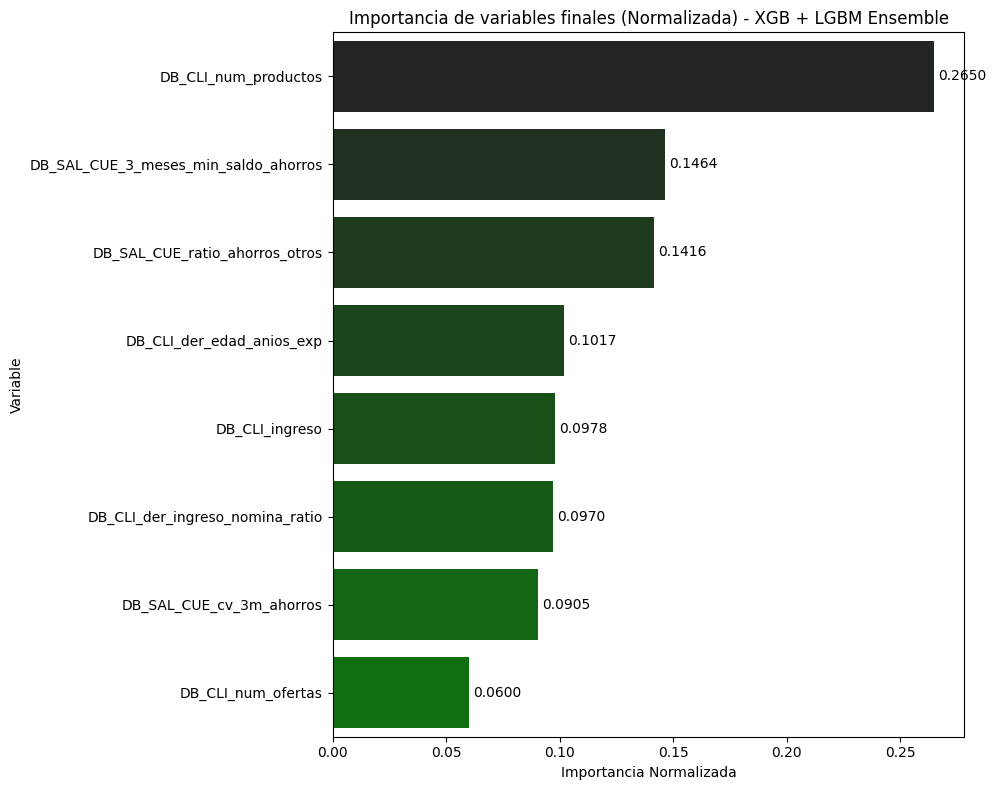

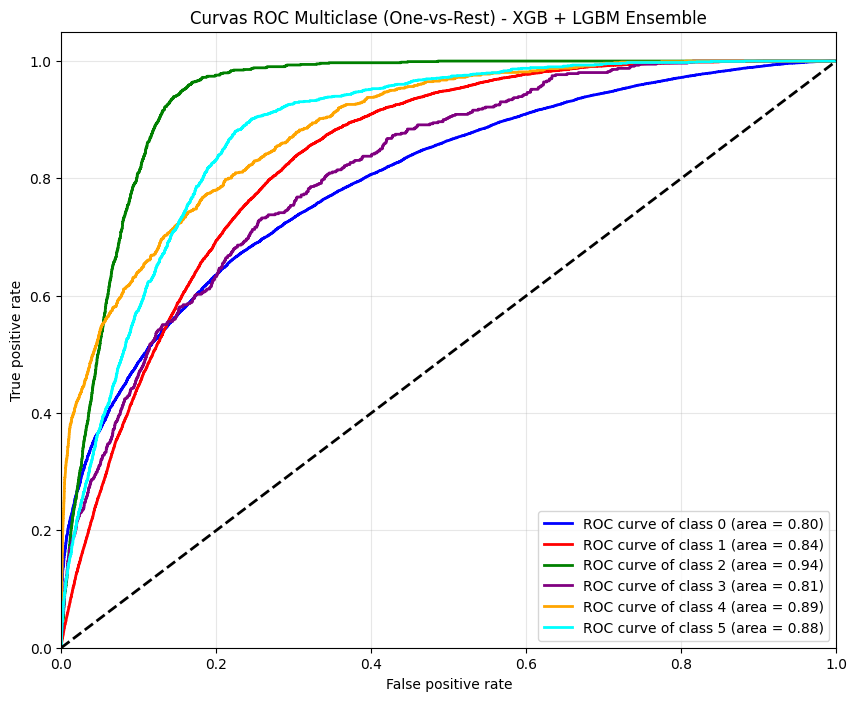

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# ==========================================
# 1. GRÁFICA DE IMPORTANCIA DE VARIABLES (ENSAMBLE)
# ==========================================

# Obtener importancias de los modelos individuales ya entrenados
xgb_imp = xgb_final.feature_importances_
lgbm_imp = lgbm_final.feature_importances_

# --- NORMALIZACIÓN (SOLUCIÓN AL PROBLEMA DE ESCALA) ---
# Dividimos cada importancia por la suma total de su modelo.
# Así, ambos modelos suman 1.0 y son comparables (escala 0 a 1).
xgb_imp_norm = xgb_imp / xgb_imp.sum()
lgbm_imp_norm = lgbm_imp / lgbm_imp.sum()

# Obtener los pesos de votación de la mejor configuración encontrada
w_xgb = best_config['xgb_voting_weight']
w_lgbm = best_config['lgbm_voting_weight']

# Calcular la importancia combinada usando las versiones NORMALIZADAS
ensemble_imp = (xgb_imp_norm * w_xgb + lgbm_imp_norm * w_lgbm) / (w_xgb + w_lgbm)

# Crear DataFrame para visualización
feat_imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': ensemble_imp
}).sort_values(by='Importance', ascending=False).head(20)

# Graficar
plt.figure(figsize=(10, 8))
ax = sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='dark:green')

# --- NUEVO: AÑADIR ETIQUETAS DE VALOR ---
# Recorremos los contenedores (las barras) y ponemos su valor al final
for i in ax.containers:
    ax.bar_label(i, fmt='%.4f', padding=3) # %.4f muestra 4 decimales

plt.title('Importancia de variables finales (Normalizada) - XGB + LGBM Ensemble')
plt.xlabel('Importancia Normalizada')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

# ==========================================
# 2. GRÁFICA CURVA ROC Y AUC (MULTICLASE)
# ==========================================

# Detectar clases únicas
classes = np.unique(y_test)
n_classes = len(classes)

# Binarizar el target para cálculo One-vs-Rest
y_test_bin = label_binarize(y_test, classes=classes)
y_score = y_test_proba # Probabilidades predichas por el ensamble

# Calcular ROC y AUC para cada clase
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Graficar
plt.figure(figsize=(10, 8))

# Colores para las clases
colors = cycle(['blue', 'red', 'green', 'purple', 'orange', 'cyan', 'magenta', 'yellow'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(classes[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Curvas ROC Multiclase (One-vs-Rest) - XGB + LGBM Ensemble')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [27]:
# ==========================================
# 3. TABLA EXACTA DE IMPORTANCIA DE VARIABLES
# ==========================================

# Mostrar la tabla con los valores exactos
print("Valores exactos de Importancia (Top 20):")
print(feat_imp_df)

# Opcional: Si quieres ver todas las variables, no solo el top 20
# pd.set_option('display.max_rows', None)
# print(pd.DataFrame({'Feature': features, 'Importance': ensemble_imp}).sort_values(by='Importance', ascending=False))

Valores exactos de Importancia (Top 20):
                                Feature  Importance
1                  DB_CLI_num_productos    0.265038
4  DB_SAL_CUE_3_meses_min_saldo_ahorros    0.146439
3        DB_SAL_CUE_ratio_ahorros_otros    0.141576
0             DB_CLI_der_edad_anios_exp    0.101723
5                        DB_CLI_ingreso    0.097793
7       DB_CLI_der_ingreso_nomina_ratio    0.096952
6              DB_SAL_CUE_cv_3m_ahorros    0.090511
2                    DB_CLI_num_ofertas    0.059968
